#***Open Quantum Simulations***



> *------------------------------------------------ An attempt by Arunav.*

We are here to have some fun by trying to learn and derive something meaningful out of the whole.

In ideal quantum mechanics, we assume:
- the system is perfectly isolated
- evolution is unitary
- no noise, no losses

But in Reality, every real quantum system interacts with something:
- electromagnetic vacuum
- phonons
- thermal baths
- control electronics

and this interaction cannot be ignored for good.

This leads to:
- decoherence
- dissipation
- loss of quantum information

Now, let us dive straight into the topic, quickly and briefly....

#***Closed vs Open systems (the big picture)***

Let us represent a Closed system in the form:

```
iℏ d/dt∣ψ(t)⟩=H∣ψ(t)⟩
```

*   pure states
*   unitary evolution
*   no environment

Open systems:


* System interacts with an environment
* We cannot track the environment explicitly
* State becomes mixed
* We use a density matrix ρ, not a wavefunction

This is fundamental for:
- real quantum hardware
- noise
- decoherence
- quantum thermodynamics

## Mathematical Framework:

1.1 Density matrix
Instead of: ∣ψ⟩,
We use:

ρ=$∑_i$ $p_i$∣$ψ_i$⟩⟨$ψ_i$∣
---
Properties:
* *Hermitian: ρ† = ρ*
* *Trace = 1*
* *Positive semi-definite*

### Lindblad Master Equation

The time evolution of the density matrix $\rho(t)$ of an open quantum system
under Markovian and completely positive dynamics is governed by the Lindblad
master equation:

$$
\frac{d\rho}{dt}
=
-\,i \left[ H, \rho \right]
+
\sum_{k}
\left(
L_k \rho L_k^\dagger
-
\frac{1}{2}
\left\{
L_k^\dagger L_k,\,
\rho
\right\}
\right)
$$

where:
- $H$ is the system Hamiltonian,
- $L_k$ are Lindblad (collapse) operators describing coupling to the environment,
- $[\cdot,\cdot]$ denotes the commutator,
- $\{\cdot,\cdot\}$ denotes the anti-commutator.
- Each $L_k$ represents a physical noise channel

#### Physical Interpretation

- The first term $-i[H,\rho]$ describes coherent (unitary) evolution.
- The Lindblad terms model irreversible processes such as decoherence,
  dissipation, and noise induced by the environment.
- This equation ensures trace preservation, positivity, and complete positivity
  of the density matrix evolution.




### Let us start with a single qubit, because
- Minimal system
- Everything is analytically understandable
- Perfect for intuition
- Extends easily to many qubits later

We choose:
- *Basis:* ∣0⟩,∣1⟩
- *Initial state:* excited state ∣1⟩

**Physical process:** Amplitude Damping

Interpretation:
Qubit loses energy to environment

***Models:***
- spontaneous emission
- $T_1$ relaxation
- photon loss

***Collapse operator:***

For amplitude damping of a single qubit, the collapse operator is given by

$$
L = \sqrt{\gamma}\,\sigma_-,
\quad
\sigma_- = |0\rangle\langle 1|
$$

where $\gamma$ is the decay rate.

In QuTiP, the Lindblad master equation is solved using the function `mesolve`,
where the collapse operators $L_k$ are passed as a list `c_ops`.


In [1]:
!pip install qutip --quiet  #installing qutip

In [2]:
# Importing libraries
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# defining the parameters
gamma = 0.1
tlist = np.linspace(0, 50, 200)


where,
*   gamma: decay rate (environment coupling strength)
*   tlist: time grid for evolution

We are solving:
ρ(t) for t∈[0,50]

In [4]:
#Intital State
psi0 = qt.basis(2,1)

***Interpretation:***

- basis(2,1) = ∣1⟩
- Initially excited qubit
- We expect it to decay to |0⟩

QuTiP will automatically convert this into a density matrix.

Next we set the Hamiltonian to 0.

And why we set it to zero is due to the following reasons:
- We isolate pure dissipation
- No coherent evolution
- Makes interpretation clean

In [5]:
# H = 0

In [6]:
H = qt.qzero(2)

In [7]:
# Next, we introduce the Collapse Operator
c_ops = [np.sqrt(gamma) * qt.sigmam()]


This is the most important line so far.
- `qt.sigmam()` = lowering operator $σ_-$
- `sqrt(gamma)` sets decay strength

This encodes environmental noise.

In [8]:
result = qt.mesolve(H, psi0, tlist, c_ops, [qt.sigmaz()])


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


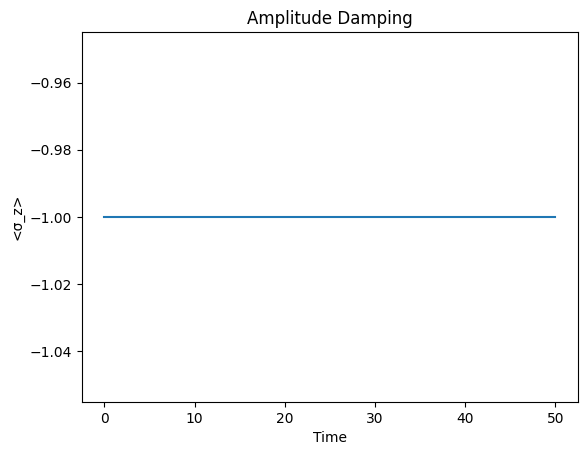

In [9]:
plt.plot(tlist, result.expect[0])
plt.xlabel('Time')
plt.ylabel(r'<σ_z>')
plt.title('Amplitude Damping')
plt.show()

We started with an eigenstate of σᶻ, and with no Hamiltonian to create superpositions, σᶻ cannot change its expectation value.

We observe: ⟨σ$_z$⟩≈−1 for all t.

**Point to remember**: Dissipation does not guarantee visible dynamics in every observable.


Now, to show/see the decoherence, we have to understand that Decoherence is about loss of coherence, not just energy loss. And we will need off-diagonal elements to see it.

Moving on, let's change the Initial state:

In [10]:
psi0 = (qt.basis(2,0) + qt.basis(2,1)).unit()

In [11]:
H = qt.qzero(2)

In [12]:
# Then just like before, we introduce the Collapse Operator
c_ops = [np.sqrt(gamma) * qt.sigmam()]

In [13]:
result = qt.mesolve(H, psi0, tlist, c_ops, [qt.sigmaz()])

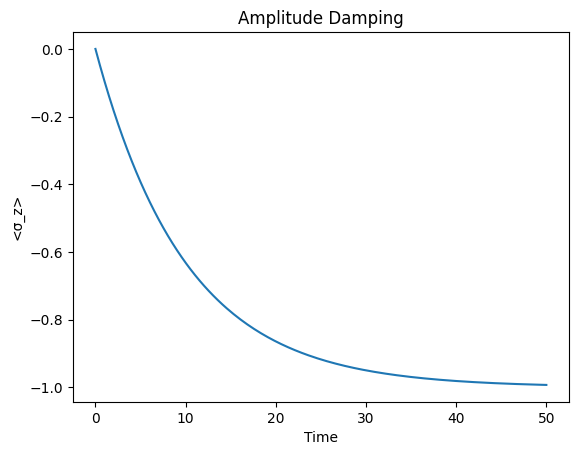

In [14]:
plt.plot(tlist, result.expect[0])
plt.xlabel('Time')
plt.ylabel(r'<σ_z>')
plt.title('Amplitude Damping')
plt.show()

Starting from an equal superposition state, amplitude damping leads to irreversible relaxation of the system toward the ground state. The expectation value ⟨σᶻ⟩ decays monotonically from zero to its steady-state value, reflecting both population relaxation and loss of quantum coherence induced by the environment.


**Now, let's visualize it on a Bloch sphere:**

*Physical meaning of amplitude damping on Bloch sphere*

Amplitude damping causes:
* contraction toward the south pole
* loss of transverse components (x, y)
* irreversible flow to a fixed point

Geometrically:
* spiral or curved path
* inward motion (loss of purity)
* final point = steady state

This is not unitary motion (unitary = rotation).

In [15]:
# Bloch sphere observables
e_ops = [qt.sigmax(), qt.sigmay(), qt.sigmaz()]

result = qt.mesolve(
    H,
    psi0,
    tlist,
    c_ops,
    e_ops
)
sx, sy, sz = result.expect


What this above code does:
- e_ops tells QuTiP what to measure
- result.expect[i] = ⟨σᵢ(t)⟩
- sx, sy, sz are Bloch coordinates

In [16]:
# Now we visualize the trajectory:

from qutip import Bloch

bloch = Bloch()

# Adding trajectory
bloch.add_points([sx, sy, sz])


In [17]:
# Adding initial and final states
bloch.add_points([[sx[0]], [sy[0]], [sz[0]]], 's')
bloch.add_points([[sx[-1]], [sy[-1]], [sz[-1]]], 's')

In [18]:
bloch.render()

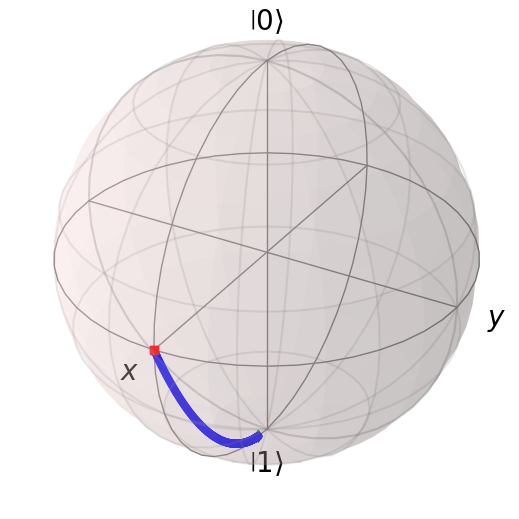

In [19]:
bloch.show()

The Bloch sphere representation provides an intuitive geometric picture of amplitude damping dynamics. Beginning from a coherent superposition state on the equator, the Bloch vector evolves along a curved inward path toward the south pole. The progressive suppression of the transverse components reflects the gradual loss of quantum coherence, while the simultaneous drift along the longitudinal axis signifies irreversible population relaxation into the ground state. Together, these features reveal the fundamentally non-unitary nature of the evolution, arising from dissipative coupling between the system and its environment as described by the Lindblad formalism.